# Part 2: NLP Sentiment Analysis on IMDB Movie Reviews

The objective of this question is to enable you to perform binary sentiment classification
using supervised Natural Language Processing techniques, compare multiple models, and
critically analyse their performance using standard metrics.

# Part 2 — NLP Sentiment Analysis on IMDB Movie Reviews (Binary Classification)

**Goal:** Train and compare at least two supervised NLP models for IMDB sentiment classification (positive vs negative),
evaluate them with standard metrics, and save the best model.

**Required outputs**
- Data analysis: review length distribution + class distribution/balance
- Preprocessing: lowercase, remove punctuation/special chars, stopword removal, stemming/lemmatization (optional)
- Tokenization
- Embeddings learned from scratch
- Train **Model 1 (baseline)** + **Model 2 (experimental)**
- Metrics: Accuracy, Precision, Recall, F1, Confusion Matrix
- Learning curves (train/val loss, val F1)
- Save best model to `saved_model.pth`

# 2.1. Data Preprocessing
1. Analyse review length distribution, class distribution and class balance.
2. Handle missing values or malformed entries, if any.
3. Perform text preprocessing, including:
    - lowercasing
    - removal of punctuation and special characters
    - stopword removal
    - stemming or lemmatization (if applicable)
4. Tokenise the processed text.
5. Create textual embeddings learned from scratch.

In [36]:
!pip install torch torchvision torchaudio
!pip install datasets pandas numpy scikit-learn matplotlib tqdm nltk

In [42]:
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


device(type='cuda')

## 2.1 Data Loading (IMDB from HuggingFace)

We load the IMDB dataset from HuggingFace (`stanfordnlp/imdb`), which contains labeled movie reviews:
- label 0 = negative
- label 1 = positive

In [43]:
ds = load_dataset("stanfordnlp/imdb")

train_ds = ds["train"]
test_ds  = ds["test"]

print(train_ds)
print(test_ds)

# Quick sanity checks
print("Train example:", train_ds[0].keys())
print("Text sample:", train_ds[0]["text"][:200])
print("Label sample:", train_ds[0]["label"])

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
Train example: dict_keys(['text', 'label'])
Text sample: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Label sample: 0


## 2.1 (1) Exploratory Data Analysis (EDA)

We analyze:
- Review length distribution (number of words)
- Class distribution and balance (positive vs negative)

,count
negative(0),12500
positive(1),12500


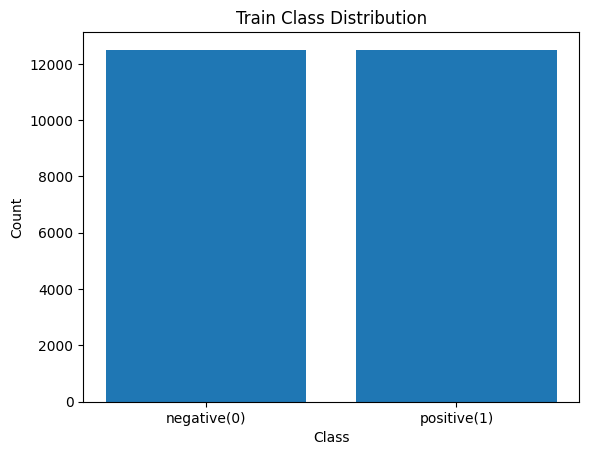

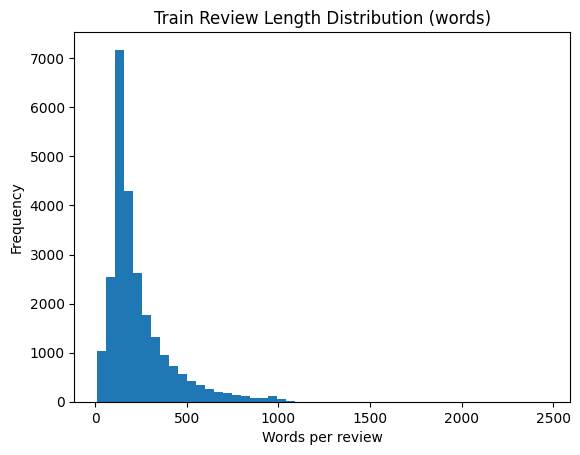

Length stats: count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
dtype: float64


In [44]:
def word_count(s: str) -> int:
    return len(s.split())

train_lengths = [word_count(x["text"]) for x in train_ds]
train_labels  = [x["label"] for x in train_ds]

# Class distribution
label_counts = pd.Series(train_labels).value_counts().sort_index()
label_counts.index = ["negative(0)", "positive(1)"]
display(label_counts)

plt.figure()
plt.bar(label_counts.index, label_counts.values)
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Length distribution
plt.figure()
plt.hist(train_lengths, bins=50)
plt.title("Train Review Length Distribution (words)")
plt.xlabel("Words per review")
plt.ylabel("Frequency")
plt.show()

print("Length stats:", pd.Series(train_lengths).describe())

## 2.1 (2) Handle Missing or Malformed Entries

We check for:
- missing text
- empty strings
- unexpected labels
Then we filter out malformed rows if any exist.

In [45]:
def is_valid_example(ex):
    if ex["text"] is None:
        return False
    if not isinstance(ex["text"], str):
        return False
    if len(ex["text"].strip()) == 0:
        return False
    if ex["label"] not in [0, 1]:
        return False
    return True

train_valid_idx = [i for i in range(len(train_ds)) if is_valid_example(train_ds[i])]
test_valid_idx  = [i for i in range(len(test_ds))  if is_valid_example(test_ds[i])]

print("Train valid:", len(train_valid_idx), "/", len(train_ds))
print("Test valid:",  len(test_valid_idx),  "/", len(test_ds))

train_ds = train_ds.select(train_valid_idx)
test_ds  = test_ds.select(test_valid_idx)

Train valid: 25000 / 25000
Test valid: 25000 / 25000


## 2.1 (3) Text Preprocessing

We apply standard preprocessing:
- lowercasing
- remove punctuation/special characters
- stopword removal
- lemmatization (optional; enabled below)

Note: aggressive preprocessing may remove sentiment cues (e.g., "not"). We keep a simple approach and
you can refine it if needed.

In [46]:
STOPWORDS = set(stopwords.words("english"))

# Optional lemmatization (can be slow). Turn off if you want faster training.
USE_LEMMATIZER = True
if USE_LEMMATIZER:
    nltk.download("wordnet")
    nltk.download("omw-1.4")
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    # Lowercase
    text = text.lower()

    # Remove HTML breaks commonly found in IMDB
    text = text.replace("<br />", " ")

    # Keep letters/numbers/spaces only
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    # Stopword removal
    tokens = [t for t in tokens if t not in STOPWORDS]

    # Lemmatization (optional)
    if USE_LEMMATIZER:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# Quick demo
print("Before:", train_ds[0]["text"][:200])
print("After :", preprocess_text(train_ds[0]["text"])[:200])

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
After : rented curious yellow video store controversy surrounded first released 1967 also heard first seized u custom ever tried enter country therefore fan film considered controversial really see plot cente


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Create a Validation Split

We split part of the training set into a validation set for:
- early stopping
- hyperparameter comparison

In [47]:
# Create validation from training
split = train_ds.train_test_split(test_size=0.1, seed=SEED)
train_ds2 = split["train"]
val_ds    = split["test"]

print("Train:", len(train_ds2), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 22500 Val: 2500 Test: 25000


## 2.1 (4) Tokenization + 2.1 (5) Embeddings Learned from Scratch

We build:
- a vocabulary from training text only
- integer token sequences
- PyTorch embedding layers are trained from scratch (no pretrained embeddings)

In [48]:
from collections import Counter

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

MAX_VOCAB = 30000   # you can change this
MAX_LEN   = 300     # truncate/pad to fixed length

def tokenize(s: str):
    return s.split()

# Build vocab on training split only
counter = Counter()
for ex in train_ds2:
    txt = preprocess_text(ex["text"])
    counter.update(tokenize(txt))

# Most common tokens
vocab_tokens = [PAD_TOKEN, UNK_TOKEN] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
stoi = {w: i for i, w in enumerate(vocab_tokens)}
itos = {i: w for w, i in stoi.items()}

PAD_ID = stoi[PAD_TOKEN]
UNK_ID = stoi[UNK_TOKEN]

def encode(text: str, max_len=MAX_LEN):
    txt = preprocess_text(text)
    toks = tokenize(txt)
    ids = [stoi.get(t, UNK_ID) for t in toks][:max_len]
    # Pad
    if len(ids) < max_len:
        ids = ids + [PAD_ID] * (max_len - len(ids))
    return ids

# Quick check
sample_ids = encode(train_ds2[0]["text"])
print("Encoded length:", len(sample_ids), "First 20 ids:", sample_ids[:20])

Encoded length: 300 First 20 ids: [19, 10687, 40, 129, 637, 68, 785, 27793, 676, 11, 569, 17, 682, 932, 112, 37, 167, 68, 3, 453]


## PyTorch Dataset and DataLoader

We wrap the encoded text + label into a PyTorch dataset, then create loaders for training/validation/testing.

In [49]:
class IMDBTorchDataset(Dataset):
    def __init__(self, hf_dataset):
        self.ds = hf_dataset

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        x = torch.tensor(encode(ex["text"]), dtype=torch.long)
        y = torch.tensor(ex["label"], dtype=torch.long)
        return x, y

BATCH_SIZE = 128

train_loader = DataLoader(IMDBTorchDataset(train_ds2), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(IMDBTorchDataset(val_ds),    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(IMDBTorchDataset(test_ds),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# 2.2 Model Training and Evaluation
You will train at least two models for sentiment classification:
  - <b>Model 1 (Baseline Model)</b>: Implement a standard sentiment classification model
to establish baseline performance.
  - <b>Model 2 (Experimental Model)</b>: Implement a second model that attempts to
improve upon the baseline through architectural or hyperparameter changes.

For each model, you must:
1. Justify the model architecture and embedding choices.
2. Evaluate performance using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Confusion Matrix

## 2.2 Model 1 (Baseline): Embedding + Mean Pooling + Linear

**Why this baseline?**
- Very standard text classifier
- Fast training
- Embedding is learned from scratch (meets requirement)
- Provides a strong, simple reference point

In [50]:
class BaselineMeanPool(nn.Module):
    def __init__(self, vocab_size, embed_dim, pad_id):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x):
        # x: [B, T]
        emb = self.embedding(x)  # [B, T, D]

        # Mask out PAD tokens for mean pooling
        mask = (x != self.pad_id).unsqueeze(-1)  # [B, T, 1]
        emb = emb * mask
        lengths = mask.sum(dim=1).clamp(min=1)   # [B, 1]
        pooled = emb.sum(dim=1) / lengths        # [B, D]

        logits = self.fc(pooled)                 # [B, 2]
        return logits

## 2.2 Model 2 (Experimental): Embedding + BiLSTM + Attention Pooling

**Why this experimental model?**
- BiLSTM models word order and context better than mean pooling
- Attention pooling helps focus on sentiment-bearing tokens
- Still uses embeddings learned from scratch

In [51]:
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_id, dropout=0.2):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)

        # Attention: score each time step
        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        emb = self.embedding(x)                  # [B, T, D]
        out, _ = self.lstm(emb)                  # [B, T, 2H]
        out = self.dropout(out)

        # Mask PAD tokens so they don't get attention
        mask = (x != self.pad_id)                # [B, T]
        scores = self.attn(out).squeeze(-1)      # [B, T]
        scores = scores.masked_fill(~mask, -1e9)

        weights = torch.softmax(scores, dim=1)   # [B, T]
        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)  # [B, 2H]

        logits = self.fc(pooled)                 # [B, 2]
        return logits

## Training Utilities

We implement:
- evaluation (Accuracy, Precision, Recall, F1)
- early stopping based on **validation F1**
- learning curve tracking (train loss, val loss, val F1)

In [52]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return acc, p, r, f1

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        n += y.size(0)

        pred = torch.argmax(logits, dim=1)
        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())

    avg_loss = total_loss / max(1, n)
    acc, p, r, f1 = compute_metrics(all_y, all_pred)
    return avg_loss, acc, p, r, f1, np.array(all_y), np.array(all_pred)

def train_one_run(model, train_loader, val_loader, cfg):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg.get("weight_decay", 0.0))

    # IMPORTANT: Remove "verbose" to avoid the error you saw in some PyTorch versions
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_state = None
    best_val_f1 = -1.0
    best_epoch = -1
    no_improve = 0

    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        total_loss = 0.0
        n = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()

            # Optional gradient clipping (stabilizes LSTM training)
            if cfg.get("grad_clip", None) is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])

            optimizer.step()

            total_loss += loss.item() * y.size(0)
            n += y.size(0)

        train_loss = total_loss / max(1, n)
        val_loss, val_acc, val_p, val_r, val_f1, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        scheduler.step(val_f1)

        # Early stopping on validation F1
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | no_improve={no_improve}")

        if no_improve >= cfg["early_stop_patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch} (val_f1={best_val_f1:.4f})")
            break

    # Restore best weights
    model.load_state_dict(best_state)
    return model, best_val_f1, history, best_epoch

## Hyperparameter Trials (Multiple Parameter Runs)

We run multiple parameter settings for:
- baseline model
- experimental model

We select the best model by **validation F1**, then save it as `saved_model.pth`.

In [57]:
vocab_size = len(vocab_tokens)

baseline_configs = [
    {"name": "baseline_e128_lr1e-3", "model_type": "baseline", "embed_dim": 128, "lr": 1e-3, "epochs": 8, "early_stop_patience": 2, "weight_decay": 0.0},
    {"name": "baseline_e200_lr5e-4", "model_type": "baseline", "embed_dim": 200, "lr": 5e-4, "epochs": 8, "early_stop_patience": 2, "weight_decay": 1e-5},
]

experimental_configs = [
    {"name": "bilstm_e128_h128_lr1e-3", "model_type": "bilstm", "embed_dim": 128, "hidden_dim": 128, "dropout": 0.2, "lr": 1e-3, "epochs": 10, "early_stop_patience": 3, "grad_clip": 1.0},
    {"name": "bilstm_e200_h128_lr5e-4", "model_type": "bilstm", "embed_dim": 200, "hidden_dim": 128, "dropout": 0.3, "lr": 5e-4, "epochs": 10, "early_stop_patience": 3, "grad_clip": 1.0, "weight_decay": 1e-5},
]

all_configs = baseline_configs + experimental_configs

results = []
histories = {}
model_files = []  # will hold file names for saved best checkpoints

best_overall = {"val_f1": -1.0, "name": None, "model": None, "cfg": None}

for cfg in all_configs:
    print("\n" + "="*60)
    print("Running:", cfg["name"])

    if cfg["model_type"] == "baseline":
        model = BaselineMeanPool(vocab_size=vocab_size, embed_dim=cfg["embed_dim"], pad_id=PAD_ID)
    else:
        model = BiLSTMAttention(
            vocab_size=vocab_size,
            embed_dim=cfg["embed_dim"],
            hidden_dim=cfg["hidden_dim"],
            pad_id=PAD_ID,
            dropout=cfg.get("dropout", 0.2)
        )

    # Train and keep best_state in memory
    model, best_val_f1, history, best_epoch = train_one_run(model, train_loader, val_loader, cfg)
    histories[cfg["name"]] = history

    # Save best checkpoint to disk as state_dict (so we can reload later)
    filename = f"{cfg['name']}_best.pth"
    # If train_one_run returned a model loaded with best weights already, save its state_dict
    torch.save(model.state_dict(), filename)
    model_files.append(filename)
    print(f"Saved best checkpoint for {cfg['name']} -> {filename}")

    # Evaluate on validation set (already best weights restored in model)
    criterion = nn.CrossEntropyLoss()
    val_loss, val_acc, val_p, val_r, val_f1, _, _ = evaluate(model, val_loader, criterion)

    results.append({
        "run": cfg["name"],
        "model_type": cfg["model_type"],
        "best_epoch": best_epoch,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_precision": val_p,
        "val_recall": val_r,
        "val_f1": val_f1,
        "checkpoint": filename
    })

    if val_f1 > best_overall["val_f1"]:
        best_overall.update({"val_f1": val_f1, "name": cfg["name"], "model": model, "cfg": cfg, "checkpoint": filename})

df_results = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(df_results)


Running: baseline_e128_lr1e-3
Epoch 01 | train_loss=0.6228 | val_loss=0.5234 | val_f1=0.8120 | no_improve=0
Epoch 02 | train_loss=0.4271 | val_loss=0.3683 | val_f1=0.8599 | no_improve=0
Epoch 03 | train_loss=0.3082 | val_loss=0.3116 | val_f1=0.8751 | no_improve=0
Epoch 04 | train_loss=0.2488 | val_loss=0.2863 | val_f1=0.8899 | no_improve=0
Epoch 05 | train_loss=0.2097 | val_loss=0.2755 | val_f1=0.8947 | no_improve=0
Epoch 06 | train_loss=0.1798 | val_loss=0.2685 | val_f1=0.9001 | no_improve=0
Epoch 07 | train_loss=0.1555 | val_loss=0.2666 | val_f1=0.8981 | no_improve=1
Epoch 08 | train_loss=0.1347 | val_loss=0.2671 | val_f1=0.9017 | no_improve=0
Saved best checkpoint for baseline_e128_lr1e-3 -> baseline_e128_lr1e-3_best.pth

Running: baseline_e200_lr5e-4
Epoch 01 | train_loss=0.6661 | val_loss=0.6318 | val_f1=0.7291 | no_improve=0
Epoch 02 | train_loss=0.5895 | val_loss=0.5428 | val_f1=0.7989 | no_improve=0
Epoch 03 | train_loss=0.4974 | val_loss=0.4597 | val_f1=0.8327 | no_improve=0


,run,model_type,best_epoch,val_loss,val_acc,val_precision,val_recall,val_f1,checkpoint
0,baseline_e128_lr1e-3,baseline,8,0.267115,0.9016,0.906024,0.897375,0.901679,baseline_e128_lr1e-3_best.pth
1,bilstm_e128_h128_lr1e-3,bilstm,3,0.280530,0.8912,0.874525,0.914877,0.894246,bilstm_e128_h128_lr1e-3_best.pth
2,bilstm_e200_h128_lr5e-4,bilstm,9,0.522856,0.8820,0.892333,0.870326,0.881192,bilstm_e200_h128_lr5e-4_best.pth
3,baseline_e200_lr5e-4,baseline,8,0.318523,0.8792,0.885391,0.872713,0.879006,baseline_e200_lr5e-4_best.pth


## Plot learning curves for every run

This cell:
- Plots train_loss, val_loss, val_f1 for each run (one figure / run).
- Plots a combined chart comparing validation F1 of all runs (helps pick best).

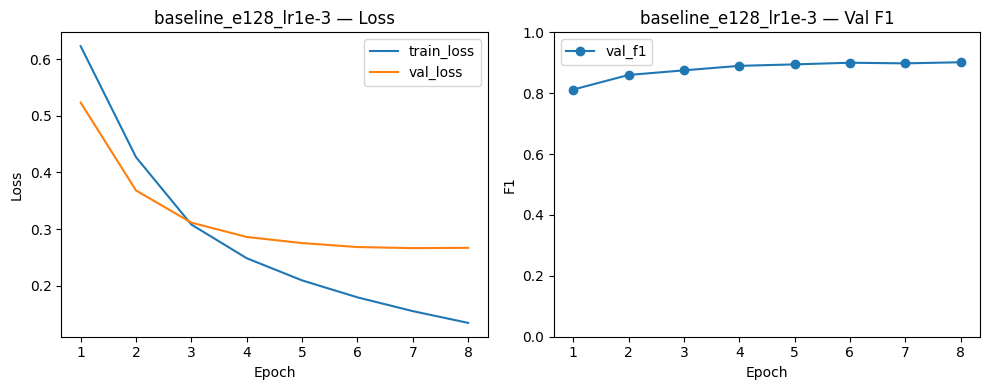

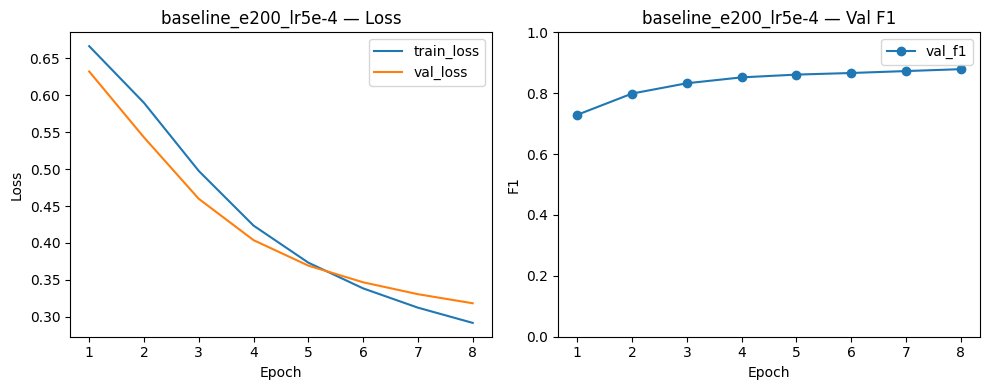

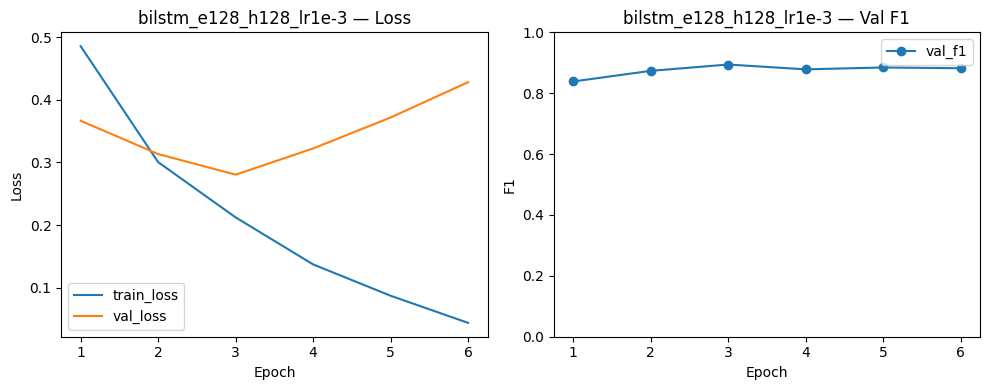

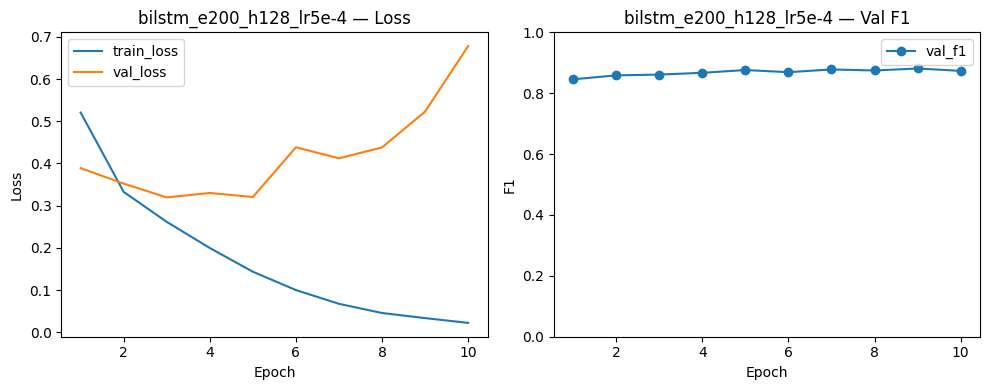

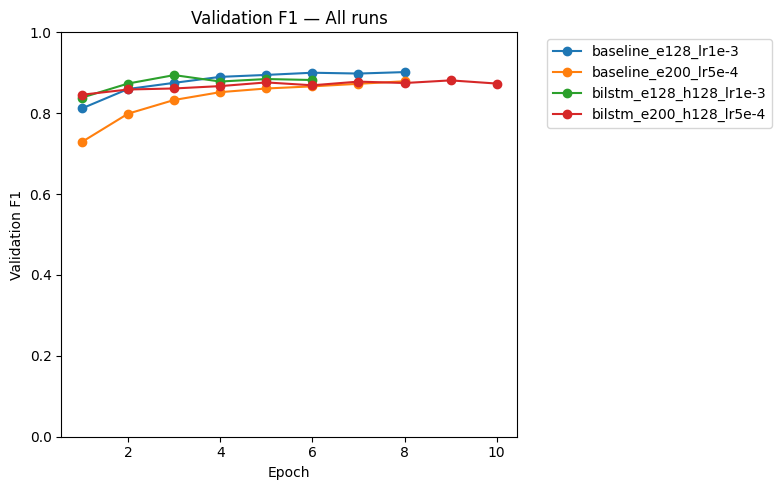

In [58]:
import math
import matplotlib.pyplot as plt

if not histories:
    raise RuntimeError("No histories found. Run the training cell that fills `histories` first.")

# Plot each run individually
for name, h in histories.items():
    epochs = range(1, len(h["train_loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, h["train_loss"], label="train_loss")
    plt.plot(epochs, h["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name} — Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, h["val_f1"], marker="o", label="val_f1")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.title(f"{name} — Val F1")
    plt.ylim(0.0, 1.0)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Combined val F1 comparison across runs
plt.figure(figsize=(8,5))
for name, h in histories.items():
    plt.plot(range(1, len(h["val_f1"])+1), h["val_f1"], marker="o", label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("Validation F1 — All runs")
plt.ylim(0.0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Evaluate every saved checkpoint on the TEST set and produce:
- a table with test metrics per run (loss, Accuracy, Precision, Recall, F1)
- confusion matrices for each run (visual + numeric)

If you saved the checkpoints to disk with the prior cell, this will load them and evaluate.

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Ensure df_results or results exist
if 'df_results' not in globals():
    raise RuntimeError("No results dataframe found. Run training and save checkpoints first.")

test_eval_rows = []
cms = {}  # store confusion matrices by run name

criterion = nn.CrossEntropyLoss()

for idx, row in df_results.iterrows():
    run_name = row["run"]
    ckpt = row.get("checkpoint", f"{run_name}_best.pth")

    # Build model instance matching the run type and cfg stored previously
    # We'll detect model_type from df_results or all_configs
    cfg = next((c for c in all_configs if c["name"] == run_name), None)
    if cfg is None:
        print("Warning: cfg not found for", run_name, "- skipping")
        continue

    if cfg["model_type"] == "baseline":
        model = BaselineMeanPool(vocab_size=vocab_size, embed_dim=cfg["embed_dim"], pad_id=PAD_ID)
    else:
        model = BiLSTMAttention(vocab_size=vocab_size, embed_dim=cfg["embed_dim"], hidden_dim=cfg["hidden_dim"], pad_id=PAD_ID, dropout=cfg.get("dropout", 0.2))

    # Load checkpoint
    try:
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state)
    except Exception as e:
        print(f"Could not load checkpoint {ckpt} for {run_name}: {e}")
        print("Skipping this run.")
        continue

    model = model.to(device)

    test_loss, test_acc, test_p, test_r, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion)
    cm = confusion_matrix(y_true, y_pred)

    test_eval_rows.append({
        "run": run_name,
        "test_loss": test_loss,
        "Accuracy": test_acc,
        "Precision": test_p,
        "Recall": test_r,
        "F1-score": test_f1,
        "checkpoint": ckpt
    })
    cms[run_name] = cm

# Show results table sorted by F1
df_test = pd.DataFrame(test_eval_rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(df_test)

,run,test_loss,Accuracy,Precision,Recall,F1-score,checkpoint
0,baseline_e128_lr1e-3,0.310755,0.87156,0.884574,0.85464,0.869349,baseline_e128_lr1e-3_best.pth
1,bilstm_e128_h128_lr1e-3,0.323173,0.86248,0.851513,0.87808,0.864592,bilstm_e128_h128_lr1e-3_best.pth
2,baseline_e200_lr5e-4,0.331237,0.86140,0.871352,0.84800,0.859518,baseline_e200_lr5e-4_best.pth
3,bilstm_e200_h128_lr5e-4,0.621677,0.85060,0.862520,0.83416,0.848103,bilstm_e200_h128_lr5e-4_best.pth


## Visualize confusion matrices for all runs

This cell will display a grid of confusion matrix heatmaps (2xN layout if many runs).

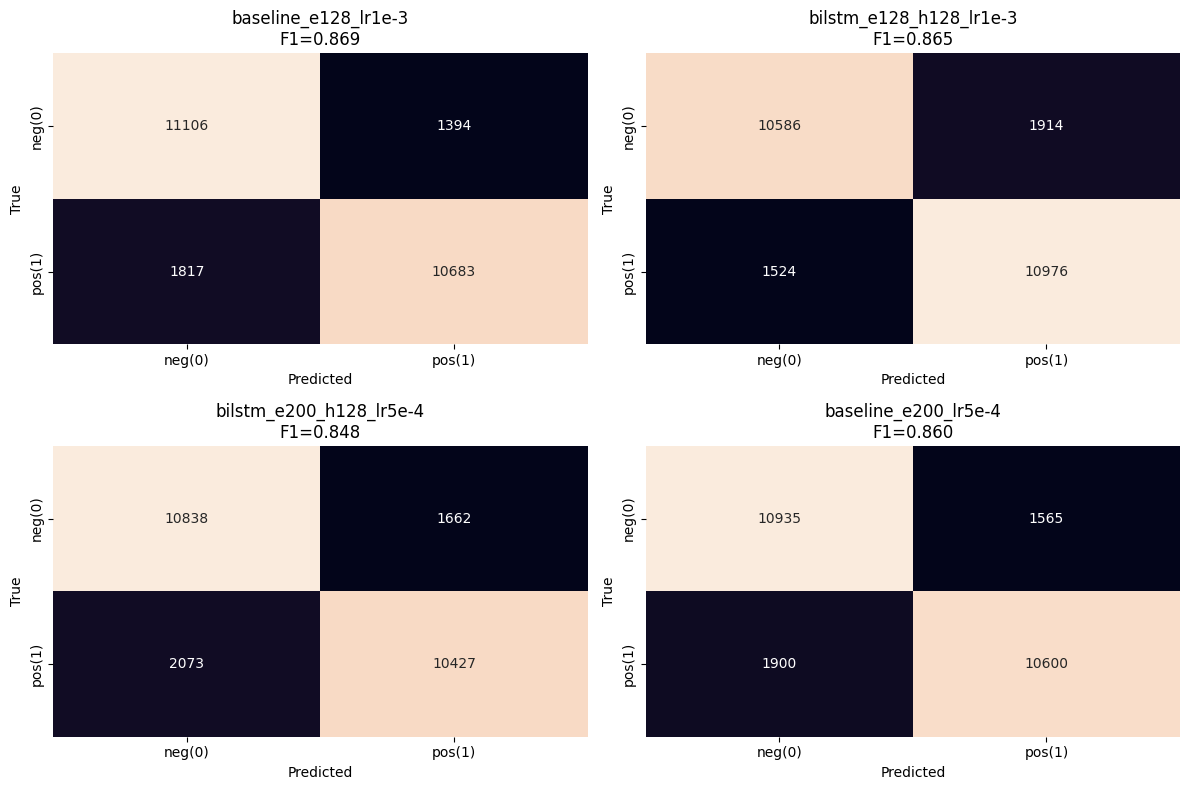


=== baseline_e128_lr1e-3 ===
[[11106  1394]
 [ 1817 10683]]

=== bilstm_e128_h128_lr1e-3 ===
[[10586  1914]
 [ 1524 10976]]

=== bilstm_e200_h128_lr5e-4 ===
[[10838  1662]
 [ 2073 10427]]

=== baseline_e200_lr5e-4 ===
[[10935  1565]
 [ 1900 10600]]


In [60]:
# Plot confusion matrices
if not cms:
    print("No confusion matrices found. Make sure previous evaluation cell ran successfully.")
else:
    names = list(cms.keys())
    n = len(names)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = axes.flatten()

    for i, name in enumerate(names):
        cm = cms[name]
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt="d", ax=ax, cbar=False)
        ax.set_title(f"{name}\nF1={df_test.loc[df_test['run']==name,'F1-score'].values[0]:.3f}" if name in df_test['run'].values else name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticklabels(["neg(0)", "pos(1)"])
        ax.set_yticklabels(["neg(0)", "pos(1)"])
    # Turn off unused axes
    for j in range(i+1, rows*cols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # Also print numeric confusion matrices
    for name, cm in cms.items():
        print(f"\n=== {name} ===")
        print(cm)

## Saved Best model

In [62]:
# Choose and save best model by TEST F1
# Assumptions:
# - `all_configs` is a list of config dicts used for training (each has "name" and "model_type" etc.)
# - Checkpoints are saved with filenames like "<run_name>_best.pth" OR df_results contains "checkpoint" column
# - evaluate(model, loader, criterion) is defined and test_loader exists
# - BaselineMeanPool and BiLSTMAttention model classes are defined
# - device variable exists

import os
from sklearn.metrics import confusion_matrix

criterion = nn.CrossEntropyLoss()

test_eval_rows = []

# Helper to create model instance given cfg
def make_model_from_cfg(cfg):
    if cfg["model_type"] == "baseline":
        return BaselineMeanPool(vocab_size=vocab_size, embed_dim=cfg["embed_dim"], pad_id=PAD_ID)
    else:
        return BiLSTMAttention(
            vocab_size=vocab_size,
            embed_dim=cfg["embed_dim"],
            hidden_dim=cfg["hidden_dim"],
            pad_id=PAD_ID,
            dropout=cfg.get("dropout", 0.2)
        )

# Build list of runs to evaluate
runs_to_check = []
if 'df_results' in globals():
    # Prefer the df_results ordering if present
    for _, r in df_results.iterrows():
        cfg = next((c for c in all_configs if c["name"] == r["run"]), None)
        if cfg is None:
            continue
        ckpt = r.get("checkpoint", f"{r['run']}_best.pth")
        runs_to_check.append((r["run"], cfg, ckpt))
else:
    # Fallback: use all_configs and assume filename pattern
    for cfg in all_configs:
        runs_to_check.append((cfg["name"], cfg, f"{cfg['name']}_best.pth"))

if len(runs_to_check) == 0:
    raise RuntimeError("No runs found to evaluate. Make sure `all_configs` or `df_results` is available.")

best = {"f1": -1.0, "run": None, "cfg": None, "ckpt": None, "model_state": None, "metrics": None, "cm": None}

print(f"Evaluating {len(runs_to_check)} run(s) on the TEST set...")

for run_name, cfg, ckpt in runs_to_check:
    if not os.path.exists(ckpt):
        print(f" - Checkpoint missing for {run_name}: {ckpt} (skipping)")
        continue

    # Instantiate model and load state
    model = make_model_from_cfg(cfg)
    try:
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state)
    except Exception as e:
        print(f" - Failed to load {ckpt} for {run_name}: {e} (skipping)")
        continue

    model = model.to(device)
    test_loss, test_acc, test_p, test_r, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion)
    cm = confusion_matrix(y_true, y_pred)

    print(f" - {run_name} | test_f1={test_f1:.4f} | Acc={test_acc:.4f} | P={test_p:.4f} | R={test_r:.4f}")

    test_eval_rows.append({
        "run": run_name,
        "checkpoint": ckpt,
        "test_loss": test_loss,
        "Accuracy": test_acc,
        "Precision": test_p,
        "Recall": test_r,
        "F1-score": test_f1
    })

    # Update best
    if test_f1 > best["f1"]:
        best.update({
            "f1": test_f1,
            "run": run_name,
            "cfg": cfg,
            "ckpt": ckpt,
            "model_state": {k: v.cpu().clone() for k, v in model.state_dict().items()},
            "metrics": (test_loss, test_acc, test_p, test_r, test_f1),
            "cm": cm
        })

# Show results table
if len(test_eval_rows) == 0:
    raise RuntimeError("No valid checkpoints were found/loaded. Ensure checkpoints exist and retry.")

df_test_summary = pd.DataFrame(test_eval_rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(df_test_summary)

# Save best model state_dict with descriptive name and also save as saved_model.pth
if best["run"] is None:
    raise RuntimeError("No best model found (all runs skipped or failed).")

best_fname = f"best_model_{best['run']}_F1_{best['f1']:.4f}.pth"
# Save descriptive filename
torch.save(best["model_state"], best_fname)
# Save canonical filename too
torch.save(best["model_state"], "saved_model.pth")

print("\nSelected best model:")
print(f" - run: {best['run']}")
print(f" - checkpoint used: {best['ckpt']}")
print(f" - test F1: {best['f1']:.4f}")
print(f" - saved files: {best_fname}  and  saved_model.pth")

# Optional: print confusion matrix for the selected best model
print("\nConfusion matrix for selected best model (rows=true, cols=pred):")
print(best["cm"])

Evaluating 4 run(s) on the TEST set...
 - baseline_e128_lr1e-3 | test_f1=0.8693 | Acc=0.8716 | P=0.8846 | R=0.8546
 - bilstm_e128_h128_lr1e-3 | test_f1=0.8646 | Acc=0.8625 | P=0.8515 | R=0.8781
 - bilstm_e200_h128_lr5e-4 | test_f1=0.8481 | Acc=0.8506 | P=0.8625 | R=0.8342
 - baseline_e200_lr5e-4 | test_f1=0.8595 | Acc=0.8614 | P=0.8714 | R=0.8480


,run,checkpoint,test_loss,Accuracy,Precision,Recall,F1-score
0,baseline_e128_lr1e-3,baseline_e128_lr1e-3_best.pth,0.310755,0.87156,0.884574,0.85464,0.869349
1,bilstm_e128_h128_lr1e-3,bilstm_e128_h128_lr1e-3_best.pth,0.323173,0.86248,0.851513,0.87808,0.864592
2,baseline_e200_lr5e-4,baseline_e200_lr5e-4_best.pth,0.331237,0.86140,0.871352,0.84800,0.859518
3,bilstm_e200_h128_lr5e-4,bilstm_e200_h128_lr5e-4_best.pth,0.621677,0.85060,0.862520,0.83416,0.848103



Selected best model:
 - run: baseline_e128_lr1e-3
 - checkpoint used: baseline_e128_lr1e-3_best.pth
 - test F1: 0.8693
 - saved files: best_model_baseline_e128_lr1e-3_F1_0.8693.pth  and  saved_model.pth

Confusion matrix for selected best model (rows=true, cols=pred):
[[11106  1394]
 [ 1817 10683]]


# 2.3. Comparative Analysis and Observations
- Compare both models using above metrics.
- Discuss observed strengths, weaknesses, and limitations.
- Briefly comment on possible improvements or future work.

## Show a few misclassified examples per run (False Positives / False Negatives)

This helps qualitative analysis in your report.

In [61]:
# This cell prints up to N misclassified examples per type per run
N = 3

# We need raw test dataset to map indices. We'll re-run evaluation loop but capture misclassified indices.
for idx, row in df_test.iterrows():
    run_name = row["run"]
    ckpt = row["checkpoint"]

    cfg = next((c for c in all_configs if c["name"] == run_name), None)
    if cfg is None:
        continue

    if cfg["model_type"] == "baseline":
        model = BaselineMeanPool(vocab_size=vocab_size, embed_dim=cfg["embed_dim"], pad_id=PAD_ID)
    else:
        model = BiLSTMAttention(vocab_size=vocab_size, embed_dim=cfg["embed_dim"], hidden_dim=cfg["hidden_dim"], pad_id=PAD_ID, dropout=cfg.get("dropout", 0.2))

    try:
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state)
    except Exception:
        continue

    model = model.to(device)
    model.eval()

    false_pos = []
    false_neg = []
    with torch.no_grad():
        for i, ex in enumerate(test_ds):   # test_ds is HF dataset
            x = torch.tensor(encode(ex["text"]), dtype=torch.long).unsqueeze(0).to(device)  # [1, T]
            y = int(ex["label"])
            logits = model(x)
            pred = int(torch.argmax(logits, dim=1).cpu().numpy()[0])
            if pred != y:
                if pred == 1 and y == 0 and len(false_pos) < N:
                    false_pos.append((ex["text"], y, pred))
                if pred == 0 and y == 1 and len(false_neg) < N:
                    false_neg.append((ex["text"], y, pred))
            if len(false_pos) >= N and len(false_neg) >= N:
                break

    print(f"\n--- Misclassifications for {run_name} ---")
    print("False Positives (pred=1 but true=0):")
    for t, y, p in false_pos:
        print("----")
        print(t[:500].replace("\n"," "))
    print("\nFalse Negatives (pred=0 but true=1):")
    for t, y, p in false_neg:
        print("----")
        print(t[:500].replace("\n"," "))


--- Misclassifications for baseline_e128_lr1e-3 ---
False Positives (pred=1 but true=0):
----
Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the script. Also, I understand that this film was made in the 1930's and people were looking to escape reality, but the script made Ann Sothern's character look weak. She kept going back and forth between suitors and I felt as though she should have stayed with Paul Kelly's character in the end. He tru
----
Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical soldier in Jesus' army. It's only when he takes a summer job as an assistant to a foul-mouthed, eccentric, once-famous and now-forgotten actress Evie Walton, (Julie Walter